# Seller Intelligence, Fulfillment SLAs & Operational Risk
**Objective**: Benchmark merchant sellers by sales volume, late delivery rates, and average customer review scores.

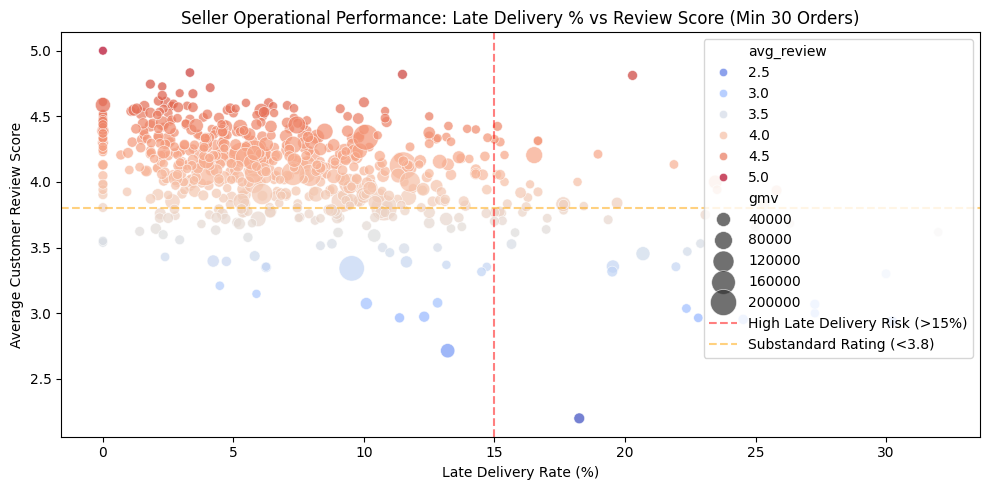

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
orders = pd.read_csv(os.path.join(proc_dir, 'clean_orders.csv'))
items = pd.read_csv(os.path.join(proc_dir, 'clean_order_items.csv'))
sellers = pd.read_csv(os.path.join(proc_dir, 'clean_sellers.csv'))

seller_orders = items.merge(orders[['order_id', 'is_late', 'review_score', 'actual_delivery_days']], on='order_id')
seller_stats = seller_orders.groupby('seller_id').agg(
    orders=('order_id', 'nunique'),
    gmv=('price', 'sum'),
    late_pct=('is_late', lambda x: x.mean() * 100),
    avg_review=('review_score', 'mean')
).reset_index()

seller_stats_filtered = seller_stats[seller_stats['orders'] >= 30]
plt.figure(figsize=(10, 5))
sns.scatterplot(data=seller_stats_filtered, x='late_pct', y='avg_review', size='gmv', hue='avg_review', palette='coolwarm', alpha=0.7, sizes=(40, 400))
plt.title('Seller Operational Performance: Late Delivery % vs Review Score (Min 30 Orders)')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Average Customer Review Score')
plt.axvline(15, color='red', linestyle='--', alpha=0.5, label='High Late Delivery Risk (>15%)')
plt.axhline(3.8, color='orange', linestyle='--', alpha=0.5, label='Substandard Rating (<3.8)')
plt.legend()
plt.tight_layout()
plt.show()